dt is 0.001 ms


100%|██████████| 3000000/3000000 [04:51<00:00, 10280.89it/s]


Creating PDMS_2_channel_0.6mm_dl_0.10mm_cfl_0.4_speed_0.262mms.mp4 movie
PDMS_2_channel_0.6mm_dl_0.10mm_cfl_0.4_speed_0.262mms.mp4 saved to C:\Users\xchenim\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\code\2_find_fric_coeffs\compare_speeds_result\trial_51\PDMS_2_channel_0.6mm_dl_0.10mm_cfl_0.4_speed_0.262mms.mp4


100%|██████████| 3000000/3000000 [04:51<00:00, 10299.47it/s]


Creating PDMS_2_channel_1.0mm_dl_0.10mm_cfl_0.4_speed_0.996mms.mp4 movie
PDMS_2_channel_1.0mm_dl_0.10mm_cfl_0.4_speed_0.996mms.mp4 saved to C:\Users\xchenim\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\code\2_find_fric_coeffs\compare_speeds_result\trial_51\PDMS_2_channel_1.0mm_dl_0.10mm_cfl_0.4_speed_0.996mms.mp4


...

Creating PDMS_2_channel_2.6mm_dl_0.10mm_cfl_0.4_speed_3.596mms.mp4 movie
PDMS_2_channel_2.6mm_dl_0.10mm_cfl_0.4_speed_3.596mms.mp4 saved to C:\Users\xchenim\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\code\2_find_fric_coeffs\compare_speeds_result\trial_51\PDMS_2_channel_2.6mm_dl_0.10mm_cfl_0.4_speed_3.596mms.mp4


100%|██████████| 3000000/3000000 [04:51<00:00, 10308.00it/s]


Creating PDMS_2_channel_2.8mm_dl_0.10mm_cfl_0.4_speed_2.789mms.mp4 movie
PDMS_2_channel_2.8mm_dl_0.10mm_cfl_0.4_speed_2.789mms.mp4 saved to C:\Users\xchenim\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\code\2_find_fric_coeffs\compare_speeds_result\trial_51\PDMS_2_channel_2.8mm_dl_0.10mm_cfl_0.4_speed_2.789mms.mp4


100%|██████████| 3000000/3000000 [04:48<00:00, 10406.22it/s]


Creating PDMS_2_channel_3.0mm_dl_0.10mm_cfl_0.4_speed_1.945mms.mp4 movie
PDMS_2_channel_3.0mm_dl_0.10mm_cfl_0.4_speed_1.945mms.mp4 saved to C:\Users\xchenim\Documents\GitHub\Bayesian_Optimization_for_Sheet_Robots\code\2_find_fric_coeffs\compare_speeds_result\trial_51\PDMS_2_channel_3.0mm_dl_0.10mm_cfl_0.4_speed_1.945mms.mp4


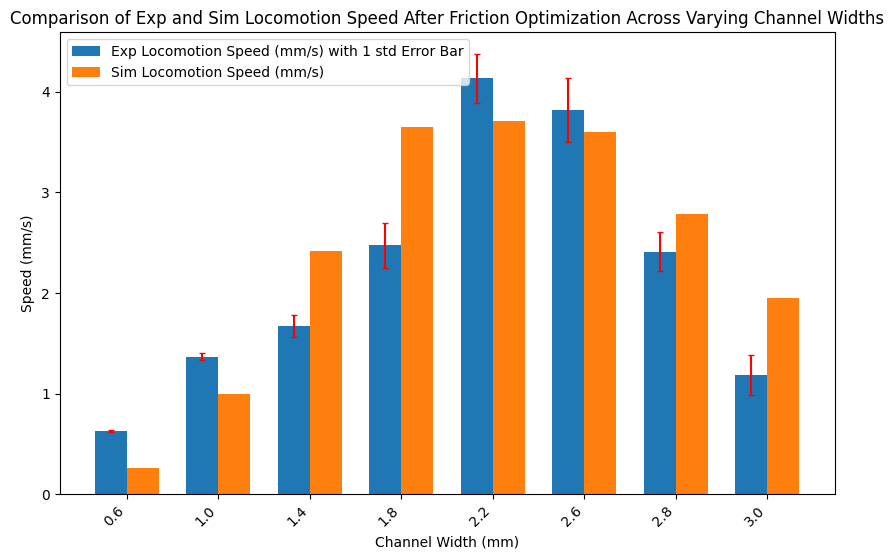

In [ ]:
"""
This script aims to evaluate the PDMS friction coefficients after optimization.
Only evaluate simple_straight.
"""
from bo_sheet.sim_wrapper_BO import run_crawling_sim, _check_self_crossings, _create_simulation_movie, _calculate_robot_speed_center_point
import numpy as np
import numpy.typing as npt
import bo_sheet.channel_preprocess_utility as cu
import os
import matplotlib.pyplot as plt
from bo_sheet.curve_compute_utils import round_down

fixed_parameters = {}
BO_parameters = {}

# USING PDMS-2 DATA
fixed_parameters['robot_length'] = 8.9 # [mm]
fixed_parameters['robot_width'] = 3.0 # [mm]
fixed_parameters['robot_thickness'] = 0.18 # [mm]
fixed_parameters['robot_n_waveform'] = 1.0 # Number of the waveform of the sinusoidal magnetization

fixed_parameters['robot_density'] = 1.795 * 1e-3 # [g/mm^3]
fixed_parameters['robot_modulus'] = 2.2 # [MPa]
fixed_parameters['robot_magnetization_density'] = 187298.43770657358 # [A/m]

fixed_parameters['save_directory'] = os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'Bayesian_Optimization_for_Sheet_Robots', \
                            'task', '2_find_fric_coeffs', 'compare_speeds_result')

target_dl = 0.1  # [mm]
cfl = 0.4

fixed_parameters['B_field'] = 0.05
fixed_parameters['B_frequency'] = 4.0

fixed_parameters['backward'] = True

fixed_parameters['final_time'] = 3e3  # Must larger than 3000.0
fixed_parameters['whether_output_movie'] = True
fixed_parameters['variation_level'] = 0.0

exp_speed_list = [
    0.62525,    1.36729,   1.667989,
    2.473419,   4.13254,   3.819223,
    2.410492,   1.186234
]

exp_std_list = [
    0.009439,   0.034639,   0.110271,
    0.22405,    0.241348,   0.319978,
    0.196568,   0.19866
]

static_mu_wall = 8.937293906750346
kinetic_mu_wall = 3.7862437848024757
static_mu_wall_end = 13.249480260330722
kinetic_mu_wall_end = 1.7875154798884043
static_mu_substrate = 0.12889650832825794
kinetic_mu_substrate = 0.017422378787529738
k_mag_den = 1.538629490914029
k_modulus = 1.1194380619912316

fixed_parameters['robot_magnetization_density'] = fixed_parameters['robot_magnetization_density'] * k_mag_den
fixed_parameters['robot_modulus'] = fixed_parameters['robot_modulus'] * k_modulus

n_elem = int(fixed_parameters['robot_length'] / target_dl)
if n_elem * target_dl < fixed_parameters['robot_length']:
    n_elem += 1
else:
    n_elem = n_elem
dl = fixed_parameters['robot_length'] / n_elem  # [mm]

fixed_parameters['dt'] = round_down(cfl * dl / np.sqrt(fixed_parameters['robot_modulus'] / fixed_parameters['robot_density']))

fixed_parameters['dist_threshold'] = fixed_parameters['robot_thickness'] / 2.0

total_channel_length = 100.0
channel_type = 'simple_straight'

channel_list = []
channel_x_mid_list = []
channel_y_mid_list = []

robot_init_pos_list = []
robot_init_director_list = []
robot_init_origin_list = []

movie_names_list = []

widths: npt.NDArray[np.float64] = np.array([0.6, 1.0, 1.4, 1.8, 2.2, 2.6, 2.8, 3.0])

for width in widths:
    channel_x_mid, channel_y_mid, channel_polygon, left_bank, right_bank = cu.generate_closed_channel(
        total_channel_length, n_bending=0, num_width_ctrl=0, max_curvature=0.0,
        min_curvature=0, max_width=width, min_width=width, max_rate_curvature=0.0,
        max_rate_width=0.0, width=width, constant_width=True, origin_offset=0.0,
        backward=fixed_parameters['backward']
    )
    # cu.plot_channel_all_info(channel_x_mid, channel_y_mid, channel_polygon, left_bank, right_bank)
    channel_list.append(channel_polygon)

    channel_x_mid_list.append(channel_x_mid)
    channel_y_mid_list.append(channel_y_mid)

    channel_seg_midline = np.column_stack((channel_x_mid, channel_y_mid))

    robot_init_pos = cu.generate_fiber_in_segment(channel_seg_midline,
                                                L_fiber=fixed_parameters['robot_length'],
                                                offset_factor=0.02,
                                                N_fiber=n_elem)
    
    robot_init_director = cu.compute_directors_from_positions(robot_init_pos)
    robot_init_origin = robot_init_pos[:, 0]

    robot_init_pos_list.append(robot_init_pos)
    robot_init_director_list.append(robot_init_director)
    robot_init_origin_list.append(robot_init_origin)

    movie_names_list.append(f"PDMS_2_channel_{width:.1f}mm")

n_elem = robot_init_pos.shape[1] - 1
magnetization_direction = np.zeros((3, n_elem))

magnetization_angles = np.linspace(0, 2 * np.pi * fixed_parameters['robot_n_waveform'], n_elem)
magnetization_direction[0, :] = np.cos(magnetization_angles)
magnetization_direction[1, :] = np.sin(magnetization_angles)
fixed_parameters['robot_n_elem'] = n_elem
fixed_parameters['mag_dir'] = magnetization_direction

fixed_parameters['channel_list'] = channel_list
fixed_parameters['channel_x_mid_list'] = channel_x_mid_list
fixed_parameters['channel_y_mid_list'] = channel_y_mid_list
fixed_parameters['robot_init_pos_list'] = robot_init_pos_list
fixed_parameters['robot_init_director_list'] = robot_init_director_list
fixed_parameters['robot_init_origin_list'] = robot_init_origin_list
fixed_parameters['movie_names_list'] = movie_names_list

kinetic_mu_substrate_array = np.full((n_elem + 1,), kinetic_mu_substrate)
static_mu_substrate_array = np.full((n_elem + 1,), static_mu_substrate)
kinetic_mu_wall_array = np.full((n_elem + 1,), kinetic_mu_wall)
static_mu_wall_array = np.full((n_elem + 1,), static_mu_wall)

kinetic_mu_wall_array[:1] = kinetic_mu_wall_end
kinetic_mu_wall_array[-1:] = kinetic_mu_wall_end
static_mu_wall_array[:1] = static_mu_wall_end
static_mu_wall_array[-1:] = static_mu_wall_end

BO_parameters["kinetic_mu_substrate_array"] = kinetic_mu_substrate_array
BO_parameters["static_mu_substrate_array"] = static_mu_substrate_array
BO_parameters["kinetic_mu_wall_array"] = kinetic_mu_wall_array
BO_parameters["static_mu_wall_array"] = static_mu_wall_array

results = []

# matplotlib.animation is incompatible with joblib.Parallel
# so it must be executed serially
for idx in range(len(fixed_parameters["channel_list"])):
    post_processing_dict, actual_final_time_in_ms = run_crawling_sim(
    fixed_parameters['robot_length'],
    fixed_parameters['robot_width'],
    fixed_parameters['robot_thickness'],
    fixed_parameters['robot_n_waveform'],
    fixed_parameters['robot_density'],
    fixed_parameters['robot_modulus'],
    fixed_parameters['robot_magnetization_density'],
    fixed_parameters['channel_list'][idx],
    fixed_parameters['dist_threshold'],
    fixed_parameters['robot_init_pos_list'][idx],
    fixed_parameters['robot_init_origin_list'][idx],
    fixed_parameters['robot_init_director_list'][idx],
    fixed_parameters['B_field'],
    fixed_parameters['B_frequency'],
    BO_parameters['kinetic_mu_substrate_array'],
    BO_parameters['static_mu_substrate_array'],
    BO_parameters['kinetic_mu_wall_array'],
    BO_parameters['static_mu_wall_array'],
    fixed_parameters['dt'],
    fixed_parameters['final_time'],
    fixed_parameters['mag_dir'],
    fixed_parameters['variation_level'],
    backward=fixed_parameters['backward'],
    n_elem=fixed_parameters['robot_n_elem']
    )

    positions_over_time = np.array(post_processing_dict["position"])

    if np.isnan(positions_over_time).any() or positions_over_time.shape[0] == 0 or actual_final_time_in_ms == np.float64(0.0):
        speed = np.float64(0.0)
        results.append(speed)

    else:
        speed = _calculate_robot_speed_center_point(positions_over_time, actual_final_time_in_ms, channel_x_mid, channel_y_mid)
        crossing_frames = _check_self_crossings(positions_over_time)
        cross_ratio = len(crossing_frames) / positions_over_time.shape[0]

        if cross_ratio > 0.0:
            speed = np.clip(speed * (1 - 400 * (cross_ratio ** 2)), a_min=0.0, a_max=None)

        results.append(speed)

    movie_name = f"PDMS_2_channel_{widths[idx]:.1f}mm_dl_{target_dl:.2f}mm_cfl_{cfl}_speed_{speed:.3f}mms.mp4"

    with open(os.path.join(fixed_parameters['save_directory'], 'speeds.txt'), 'a') as file:
        file.write(f"{speed}\n")
        file.close()

    if fixed_parameters['whether_output_movie']:
        _create_simulation_movie(
            positions_over_time,
            fixed_parameters['channel_list'][idx],
            movie_name,
            fixed_parameters['save_directory'],
            fixed_parameters['backward']
        )

x = np.arange(len(exp_speed_list))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
# Bars for exp_speed_list
bar1 = ax.bar(x - bar_width / 2, exp_speed_list, bar_width, 
              label='Exp Locomotion Speed (mm/s) with 1 std Error Bar', 
              yerr=exp_std_list,
              capsize=2.0,
              ecolor='red',
              alpha=1.0)
bar2 = ax.bar(x + bar_width / 2, results, bar_width, label='Sim Locomotion Speed (mm/s)')
ax.set_xlabel('Channel Width (mm)')
ax.set_ylabel('Speed (mm/s)')
ax.set_title('Comparison of Exp and Sim Locomotion Speed After Friction Optimization Across Varying Channel Widths')
ax.set_xticks(x)

width_labels = [f"{w:.1f}" for w in widths]
ax.set_xticklabels(width_labels, rotation=45, ha='right')

ax.legend()
plt.show()